# 05 — Underlying Baseline Models for the Three Research Questions

This notebook benchmarks multiple model families using both the **strict** and **relaxed** underlying datasets.

## Research questions

### RQ1 — Direction

> Can intraday market features predict whether SPX will move Up or Down during the final hour?

This is treated as a binary classification problem.

### RQ2 — Magnitude

> To what extent can intraday market features predict the magnitude of the final-hour SPX movement?

This is treated as a regression problem using the absolute final-hour return in basis points.

### RQ3 — Large movements and feature importance

> Which intraday features are most important in predicting large end-of-day movements?

A large movement is defined using the 75th percentile of the **strict training-period** absolute return. The same fixed threshold is applied to both datasets. Feature importance is evaluated using validation-period permutation importance and aggregated into economic feature families.

## Experimental design

- Strict and relaxed datasets use identical calendar split boundaries.
- The test set is locked by default.
- Preprocessing occurs inside scikit-learn pipelines.
- Training evaluation uses expanding-window `TimeSeriesSplit`.
- Model and dataset selection uses training and validation results only.
- The final test evaluation runs only after `RUN_FINAL_TEST = True`.

The purpose of this notebook is to establish a transparent underlying-only benchmark before adding options data.

## 1. Environment and project discovery

The notebook uses scikit-learn models only, avoiding optional modelling libraries so that it remains portable.

In [1]:
from pathlib import Path
import json
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.special import expit
from scipy.stats import spearmanr

from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    AdaBoostClassifier,
    ExtraTreesClassifier,
    ExtraTreesRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    HistGradientBoostingClassifier,
    HistGradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import (
    ElasticNet,
    Lasso,
    LogisticRegression,
    Ridge,
)
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    log_loss,
    matthews_corrcoef,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import (
    KNeighborsClassifier,
    KNeighborsRegressor,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler, StandardScaler
from sklearn.svm import SVC, SVR
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

RANDOM_STATE = 42

pd.set_option("display.max_columns", 150)
pd.set_option("display.width", 220)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")


def locate_project_root(start: Path) -> Path:
    start = start.resolve()

    for candidate in [start, *start.parents]:
        if (candidate / "data" / "market.duckdb").exists():
            return candidate

    raise FileNotFoundError(
        "Could not find data/market.duckdb. "
        "Place this notebook inside the Massive database project."
    )


PROJECT_ROOT = locate_project_root(Path.cwd())
DATA_ROOT = PROJECT_ROOT / "data"
DERIVED_ROOT = DATA_ROOT / "derived"
OUTPUT_ROOT = PROJECT_ROOT / "outputs"
MODEL_ROOT = OUTPUT_ROOT / "baseline_models"
FIGURE_ROOT = MODEL_ROOT / "figures"
TABLE_ROOT = MODEL_ROOT / "tables"
MODEL_ROOT.mkdir(parents=True, exist_ok=True)
FIGURE_ROOT.mkdir(parents=True, exist_ok=True)
TABLE_ROOT.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Model output:", MODEL_ROOT)


def save_figure(fig, filename: str) -> Path:
    path = FIGURE_ROOT / filename
    fig.tight_layout()
    fig.savefig(path, dpi=220, bbox_inches="tight")
    return path

Project root: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation
Model output: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models


## 2. Load strict and relaxed split datasets

In [2]:
STRICT_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_strict_split.parquet"
)

RELAXED_PATH = (
    DERIVED_ROOT
    / "daily_underlying_model_dataset_relaxed_split.parquet"
)

if not STRICT_PATH.exists() or not RELAXED_PATH.exists():
    raise FileNotFoundError(
        "Run 04_build_strict_and_relaxed_datasets.ipynb first."
    )


def load_variant(path: Path, expected_name: str) -> pd.DataFrame:
    frame = pd.read_parquet(path)
    frame["session_date"] = pd.to_datetime(frame["session_date"])
    frame = frame.sort_values("session_date").reset_index(drop=True)

    required = {
        "session_date",
        "data_split",
        "final_hour_return",
        "target_up",
    }

    missing = required.difference(frame.columns)

    if missing:
        raise ValueError(
            f"{expected_name} is missing columns: {sorted(missing)}"
        )

    return frame


strict_data = load_variant(STRICT_PATH, "strict")
relaxed_data = load_variant(RELAXED_PATH, "relaxed")

datasets = {
    "Strict": strict_data,
    "Relaxed": relaxed_data,
}

coverage_rows = []

for variant, frame in datasets.items():
    for split_name in ["Train", "Validation", "Test"]:
        subset = frame[frame["data_split"].eq(split_name)]

        coverage_rows.append(
            {
                "dataset_variant": variant,
                "data_split": split_name,
                "sessions": len(subset),
                "first_date": subset["session_date"].min(),
                "last_date": subset["session_date"].max(),
                "up_sessions": int(subset["target_up"].sum()),
                "down_sessions": int(subset["target_up"].eq(0).sum()),
            }
        )

coverage = pd.DataFrame(coverage_rows)
display(coverage)

assert (
    strict_data.loc[
        strict_data["data_split"].eq("Train"),
        "session_date",
    ].max()
    ==
    relaxed_data.loc[
        relaxed_data["data_split"].eq("Train"),
        "session_date",
    ].max()
)

assert (
    strict_data.loc[
        strict_data["data_split"].eq("Validation"),
        "session_date",
    ].max()
    ==
    relaxed_data.loc[
        relaxed_data["data_split"].eq("Validation"),
        "session_date",
    ].max()
)

print("Common calendar boundaries verified.")

,dataset_variant,data_split,sessions,first_date,last_date,up_sessions,down_sessions
0,Strict,Train,303,2024-07-18,2025-12-03,147,156
1,Strict,Validation,65,2025-12-04,2026-03-20,29,36
2,Strict,Test,66,2026-03-23,2026-07-17,40,26
3,Relaxed,Train,334,2024-07-18,2025-12-03,158,176
4,Relaxed,Validation,71,2025-12-04,2026-03-20,32,39
5,Relaxed,Test,81,2026-03-23,2026-07-17,50,31


Common calendar boundaries verified.


## 3. Freeze the feature set

The modelling features exclude:

- target-construction variables such as `spx_at_close`;
- raw market levels such as `spx_at_1500` and `spy_at_1500`;
- data-quality counters;
- the exact duplicate `dist_from_open_pct`;
- the highly redundant `spy_ret_open_to_1500`.

ATR is converted from index points to a percentage of SPX at the cutoff.

The same features are used for both dataset variants and all three research questions.

In [3]:
BASE_FEATURES = [
    # SPX momentum
    "ret_open_to_1500",
    "ret_last_15m",
    "ret_last_30m",
    "ret_last_60m",
    "momentum_accel_60m_vs_prior",

    # VIX state and movement
    "vix_level_1500",
    "vix_ret_last_15m",
    "vix_ret_last_30m",
    "vix_ret_last_60m",

    # Realised volatility
    "realized_vol_30m",
    "realized_vol_60m",
    "realized_vol_120m",
    "rv_open_to_1500",

    # SPY volume and VWAP
    "spy_volume_last_30m",
    "spy_volume_last_60m",
    "spy_cum_volume_to_1500",
    "spy_volume_accel_60m_vs_avg",
    "spy_dist_from_vwap_pct",

    # Intraday price positioning
    "position_in_day_range",
    "dist_from_day_high_pct",
    "dist_from_day_low_pct",

    # Derived percentage ATR
    "atr_pct_open_to_1500",
]

FEATURE_GROUPS = {
    "Momentum": [
        "ret_open_to_1500",
        "ret_last_15m",
        "ret_last_30m",
        "ret_last_60m",
        "momentum_accel_60m_vs_prior",
    ],
    "VIX": [
        "vix_level_1500",
        "vix_ret_last_15m",
        "vix_ret_last_30m",
        "vix_ret_last_60m",
    ],
    "Volatility": [
        "realized_vol_30m",
        "realized_vol_60m",
        "realized_vol_120m",
        "rv_open_to_1500",
        "atr_pct_open_to_1500",
    ],
    "Volume and VWAP": [
        "spy_volume_last_30m",
        "spy_volume_last_60m",
        "spy_cum_volume_to_1500",
        "spy_volume_accel_60m_vs_avg",
        "spy_dist_from_vwap_pct",
    ],
    "Price positioning": [
        "position_in_day_range",
        "dist_from_day_high_pct",
        "dist_from_day_low_pct",
    ],
}


def prepare_features(frame: pd.DataFrame) -> pd.DataFrame:
    result = frame.copy()

    result["atr_pct_open_to_1500"] = (
        result["atr_open_to_1500"]
        / result["spx_at_1500"]
    )

    missing = set(BASE_FEATURES).difference(result.columns)

    if missing:
        raise ValueError(
            f"Missing modelling features: {sorted(missing)}"
        )

    result[BASE_FEATURES] = result[
        BASE_FEATURES
    ].replace([np.inf, -np.inf], np.nan)

    return result


datasets = {
    variant: prepare_features(frame)
    for variant, frame in datasets.items()
}

feature_audit = pd.DataFrame(
    {
        "feature": BASE_FEATURES,
        "strict_missing": [
            int(strict_data.get(feature, pd.Series(dtype=float)).isna().sum())
            if feature in strict_data.columns
            else np.nan
            for feature in BASE_FEATURES
        ],
        "feature_group": [
            next(
                group
                for group, group_features in FEATURE_GROUPS.items()
                if feature in group_features
            )
            for feature in BASE_FEATURES
        ],
    }
)

display(feature_audit)
print("Number of features:", len(BASE_FEATURES))

,feature,strict_missing,feature_group
0,ret_open_to_1500,0.000000,Momentum
1,ret_last_15m,0.000000,Momentum
2,ret_last_30m,0.000000,Momentum
3,ret_last_60m,0.000000,Momentum
4,momentum_accel_60m_vs_prior,0.000000,Momentum
5,vix_level_1500,0.000000,VIX
6,vix_ret_last_15m,0.000000,VIX
7,vix_ret_last_30m,0.000000,VIX
8,vix_ret_last_60m,0.000000,VIX
9,realized_vol_30m,0.000000,Volatility


Number of features: 22


## 4. Define the three targets

### RQ1 target

`target_up`: 1 for Up and 0 for Down.

### RQ2 target

Absolute final-hour return expressed in basis points.

### RQ3 target

A large movement is an absolute final-hour return at or above the 75th percentile of the strict training period. This threshold is frozen and applied to every split and both dataset variants.

In [4]:
LARGE_MOVE_QUANTILE = 0.75

strict_train_returns = strict_data.loc[
    strict_data["data_split"].eq("Train"),
    "final_hour_return",
].abs()

LARGE_MOVE_THRESHOLD_RETURN = float(
    strict_train_returns.quantile(
        LARGE_MOVE_QUANTILE
    )
)

LARGE_MOVE_THRESHOLD_BPS = (
    LARGE_MOVE_THRESHOLD_RETURN * 10_000
)

for variant, frame in datasets.items():
    frame["target_magnitude_bps"] = (
        frame["final_hour_return"].abs() * 10_000
    )

    frame["target_large_move"] = (
        frame["final_hour_return"].abs()
        >= LARGE_MOVE_THRESHOLD_RETURN
    ).astype("int8")

target_rows = []

for variant, frame in datasets.items():
    for split_name in ["Train", "Validation", "Test"]:
        subset = frame[frame["data_split"].eq(split_name)]

        target_rows.append(
            {
                "dataset_variant": variant,
                "data_split": split_name,
                "sessions": len(subset),
                "up_pct": subset["target_up"].mean() * 100,
                "mean_magnitude_bps": subset[
                    "target_magnitude_bps"
                ].mean(),
                "large_move_sessions": int(
                    subset["target_large_move"].sum()
                ),
                "large_move_pct": (
                    subset["target_large_move"].mean() * 100
                ),
            }
        )

target_summary = pd.DataFrame(target_rows)

print(
    f"Large-movement threshold: "
    f"{LARGE_MOVE_THRESHOLD_BPS:.2f} basis points"
)
display(target_summary)

Large-movement threshold: 27.50 basis points


,dataset_variant,data_split,sessions,up_pct,mean_magnitude_bps,large_move_sessions,large_move_pct
0,Strict,Train,303,48.514851,21.400786,76,25.082508
1,Strict,Validation,65,44.615385,19.648307,15,23.076923
2,Strict,Test,66,60.606061,16.910412,12,18.181818
3,Relaxed,Train,334,47.305389,20.473457,78,23.353293
4,Relaxed,Validation,71,45.070423,18.429100,15,21.126761
5,Relaxed,Test,81,61.728395,16.126760,13,16.049383


## 5. Model libraries

The model set deliberately spans several modelling assumptions:

- naive baselines;
- linear and regularised models;
- distance-based models;
- kernel methods;
- probabilistic models;
- single trees;
- bagging ensembles;
- boosting ensembles;
- a small neural network.

Hyperparameters are deliberately modest because this is a baseline comparison rather than an exhaustive search.

In [5]:
def scaled_classifier(estimator) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            ("model", estimator),
        ]
    )


def unscaled_classifier(estimator) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", estimator),
        ]
    )


def scaled_regressor(estimator) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", RobustScaler()),
            ("model", estimator),
        ]
    )


def unscaled_regressor(estimator) -> Pipeline:
    return Pipeline(
        [
            ("imputer", SimpleImputer(strategy="median")),
            ("model", estimator),
        ]
    )


CLASSIFICATION_MODELS = {
    "Dummy Majority": unscaled_classifier(
        DummyClassifier(strategy="most_frequent")
    ),
    "Logistic L1": scaled_classifier(
        LogisticRegression(
            penalty="l1",
            solver="liblinear",
            C=0.5,
            class_weight="balanced",
            max_iter=2_000,
            random_state=RANDOM_STATE,
        )
    ),
    "Logistic L2": scaled_classifier(
        LogisticRegression(
            penalty="l2",
            solver="liblinear",
            C=1.0,
            class_weight="balanced",
            max_iter=2_000,
            random_state=RANDOM_STATE,
        )
    ),
    "Logistic ElasticNet": scaled_classifier(
        LogisticRegression(
            penalty="elasticnet",
            solver="saga",
            l1_ratio=0.5,
            C=0.5,
            class_weight="balanced",
            max_iter=4_000,
            random_state=RANDOM_STATE,
        )
    ),
    "Gaussian Naive Bayes": scaled_classifier(
        GaussianNB()
    ),
    "K-Nearest Neighbours": scaled_classifier(
        KNeighborsClassifier(
            n_neighbors=15,
            weights="distance",
        )
    ),
    "RBF SVC": scaled_classifier(
        SVC(
            C=1.0,
            kernel="rbf",
            gamma="scale",
            probability=True,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    ),
    "Decision Tree": unscaled_classifier(
        DecisionTreeClassifier(
            max_depth=4,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )
    ),
    "Random Forest": unscaled_classifier(
        RandomForestClassifier(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    ),
    "Extra Trees": unscaled_classifier(
        ExtraTreesClassifier(
            n_estimators=300,
            max_depth=5,
            min_samples_leaf=5,
            max_features="sqrt",
            class_weight="balanced",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    ),
    "AdaBoost": unscaled_classifier(
        AdaBoostClassifier(
            n_estimators=150,
            learning_rate=0.05,
            random_state=RANDOM_STATE,
        )
    ),
    "Gradient Boosting": unscaled_classifier(
        GradientBoostingClassifier(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=2,
            min_samples_leaf=8,
            random_state=RANDOM_STATE,
        )
    ),
    "Histogram Gradient Boosting": unscaled_classifier(
        HistGradientBoostingClassifier(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            min_samples_leaf=12,
            l2_regularization=1.0,
            random_state=RANDOM_STATE,
        )
    ),
    "MLP Neural Network": scaled_classifier(
        MLPClassifier(
            hidden_layer_sizes=(24, 12),
            alpha=0.01,
            learning_rate_init=0.001,
            max_iter=1_500,
            early_stopping=True,
            validation_fraction=0.15,
            random_state=RANDOM_STATE,
        )
    ),
}


REGRESSION_MODELS = {
    "Dummy Median": unscaled_regressor(
        DummyRegressor(strategy="median")
    ),
    "Ridge Regression": scaled_regressor(
        Ridge(alpha=10.0)
    ),
    "Lasso Regression": scaled_regressor(
        Lasso(
            alpha=0.05,
            max_iter=10_000,
            random_state=RANDOM_STATE,
        )
    ),
    "Elastic Net": scaled_regressor(
        ElasticNet(
            alpha=0.05,
            l1_ratio=0.5,
            max_iter=10_000,
            random_state=RANDOM_STATE,
        )
    ),
    "RBF SVR": scaled_regressor(
        SVR(
            C=10.0,
            epsilon=1.0,
            kernel="rbf",
            gamma="scale",
        )
    ),
    "K-Nearest Neighbours": scaled_regressor(
        KNeighborsRegressor(
            n_neighbors=15,
            weights="distance",
        )
    ),
    "Decision Tree": unscaled_regressor(
        DecisionTreeRegressor(
            max_depth=4,
            min_samples_leaf=10,
            random_state=RANDOM_STATE,
        )
    ),
    "Random Forest": unscaled_regressor(
        RandomForestRegressor(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=5,
            max_features="sqrt",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    ),
    "Extra Trees": unscaled_regressor(
        ExtraTreesRegressor(
            n_estimators=300,
            max_depth=6,
            min_samples_leaf=5,
            max_features="sqrt",
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )
    ),
    "Gradient Boosting": unscaled_regressor(
        GradientBoostingRegressor(
            n_estimators=150,
            learning_rate=0.05,
            max_depth=2,
            min_samples_leaf=8,
            loss="huber",
            random_state=RANDOM_STATE,
        )
    ),
    "Histogram Gradient Boosting": unscaled_regressor(
        HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=15,
            min_samples_leaf=12,
            l2_regularization=1.0,
            loss="absolute_error",
            random_state=RANDOM_STATE,
        )
    ),
}

print("Classification models:", len(CLASSIFICATION_MODELS))
print("Regression models:", len(REGRESSION_MODELS))

Classification models: 14
Regression models: 11


## 6. Evaluation functions

Training performance is estimated using five expanding folds. Each model is then refitted on the complete training period and evaluated on the fixed validation period.

In [6]:
N_TIME_SERIES_SPLITS = 5


def probability_predictions(model, X: pd.DataFrame) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        probabilities = model.predict_proba(X)
        return probabilities[:, 1]

    if hasattr(model, "decision_function"):
        return expit(model.decision_function(X))

    return model.predict(X).astype(float)


def safe_auc(y_true, y_probability) -> float:
    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(
        roc_auc_score(y_true, y_probability)
    )


def safe_average_precision(y_true, y_probability) -> float:
    if len(np.unique(y_true)) < 2:
        return np.nan

    return float(
        average_precision_score(
            y_true,
            y_probability,
        )
    )


def classification_metrics(
    y_true,
    y_pred,
    y_probability,
) -> dict:
    clipped_probability = np.clip(
        y_probability,
        1e-6,
        1 - 1e-6,
    )

    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            y_pred,
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            zero_division=0,
        ),
        "roc_auc": safe_auc(
            y_true,
            y_probability,
        ),
        "average_precision": safe_average_precision(
            y_true,
            y_probability,
        ),
        "mcc": matthews_corrcoef(
            y_true,
            y_pred,
        ),
        "brier": brier_score_loss(
            y_true,
            clipped_probability,
        ),
        "log_loss": log_loss(
            y_true,
            np.column_stack(
                [
                    1 - clipped_probability,
                    clipped_probability,
                ]
            ),
            labels=[0, 1],
        ),
    }


def regression_metrics(
    y_true,
    y_pred,
) -> dict:
    correlation = spearmanr(
        y_true,
        y_pred,
        nan_policy="omit",
    ).statistic

    return {
        "mae_bps": mean_absolute_error(
            y_true,
            y_pred,
        ),
        "rmse_bps": math.sqrt(
            mean_squared_error(
                y_true,
                y_pred,
            )
        ),
        "r2": r2_score(
            y_true,
            y_pred,
        ),
        "spearman": correlation,
    }


def classification_benchmark(
    frame: pd.DataFrame,
    variant_name: str,
    target_column: str,
    task_name: str,
) -> pd.DataFrame:
    train = frame[
        frame["data_split"].eq("Train")
    ].sort_values("session_date")

    validation = frame[
        frame["data_split"].eq("Validation")
    ].sort_values("session_date")

    X_train = train[BASE_FEATURES]
    y_train = train[target_column].astype(int)

    X_validation = validation[BASE_FEATURES]
    y_validation = validation[target_column].astype(int)

    splitter = TimeSeriesSplit(
        n_splits=N_TIME_SERIES_SPLITS
    )

    rows = []

    for model_name, model_template in CLASSIFICATION_MODELS.items():
        fold_metrics = []

        for fold_number, (fit_index, fold_index) in enumerate(
            splitter.split(X_train),
            start=1,
        ):
            model = clone(model_template)

            X_fit = X_train.iloc[fit_index]
            y_fit = y_train.iloc[fit_index]
            X_fold = X_train.iloc[fold_index]
            y_fold = y_train.iloc[fold_index]

            model.fit(X_fit, y_fit)

            fold_pred = model.predict(X_fold)
            fold_probability = probability_predictions(
                model,
                X_fold,
            )

            metrics = classification_metrics(
                y_fold,
                fold_pred,
                fold_probability,
            )

            metrics["fold"] = fold_number
            fold_metrics.append(metrics)

        fold_frame = pd.DataFrame(fold_metrics)

        final_model = clone(model_template)
        final_model.fit(X_train, y_train)

        validation_pred = final_model.predict(X_validation)
        validation_probability = probability_predictions(
            final_model,
            X_validation,
        )

        validation_metrics = classification_metrics(
            y_validation,
            validation_pred,
            validation_probability,
        )

        row = {
            "task": task_name,
            "dataset_variant": variant_name,
            "model": model_name,
            "cv_balanced_accuracy_mean": (
                fold_frame["balanced_accuracy"].mean()
            ),
            "cv_balanced_accuracy_std": (
                fold_frame["balanced_accuracy"].std()
            ),
            "cv_roc_auc_mean": fold_frame["roc_auc"].mean(),
            "cv_average_precision_mean": (
                fold_frame["average_precision"].mean()
            ),
            "validation_sessions": len(validation),
        }

        row.update(
            {
                f"validation_{key}": value
                for key, value in validation_metrics.items()
            }
        )

        rows.append(row)

    return pd.DataFrame(rows)


def regression_benchmark(
    frame: pd.DataFrame,
    variant_name: str,
) -> pd.DataFrame:
    train = frame[
        frame["data_split"].eq("Train")
    ].sort_values("session_date")

    validation = frame[
        frame["data_split"].eq("Validation")
    ].sort_values("session_date")

    X_train = train[BASE_FEATURES]
    y_train = train["target_magnitude_bps"]

    X_validation = validation[BASE_FEATURES]
    y_validation = validation["target_magnitude_bps"]

    splitter = TimeSeriesSplit(
        n_splits=N_TIME_SERIES_SPLITS
    )

    rows = []

    for model_name, model_template in REGRESSION_MODELS.items():
        fold_metrics = []

        for fold_number, (fit_index, fold_index) in enumerate(
            splitter.split(X_train),
            start=1,
        ):
            model = clone(model_template)

            X_fit = X_train.iloc[fit_index]
            y_fit = y_train.iloc[fit_index]
            X_fold = X_train.iloc[fold_index]
            y_fold = y_train.iloc[fold_index]

            model.fit(X_fit, y_fit)
            fold_pred = model.predict(X_fold)

            metrics = regression_metrics(
                y_fold,
                fold_pred,
            )

            metrics["fold"] = fold_number
            fold_metrics.append(metrics)

        fold_frame = pd.DataFrame(fold_metrics)

        final_model = clone(model_template)
        final_model.fit(X_train, y_train)
        validation_pred = final_model.predict(
            X_validation
        )

        validation_metrics = regression_metrics(
            y_validation,
            validation_pred,
        )

        row = {
            "task": "RQ2 Magnitude",
            "dataset_variant": variant_name,
            "model": model_name,
            "cv_mae_bps_mean": fold_frame[
                "mae_bps"
            ].mean(),
            "cv_mae_bps_std": fold_frame[
                "mae_bps"
            ].std(),
            "cv_rmse_bps_mean": fold_frame[
                "rmse_bps"
            ].mean(),
            "cv_spearman_mean": fold_frame[
                "spearman"
            ].mean(),
            "validation_sessions": len(validation),
        }

        row.update(
            {
                f"validation_{key}": value
                for key, value in validation_metrics.items()
            }
        )

        rows.append(row)

    return pd.DataFrame(rows)

## 7. Rule-based direction baselines

These baselines establish whether machine-learning models improve on simple economic rules.

In [7]:
def direction_rule_baselines(
    frame: pd.DataFrame,
    variant_name: str,
) -> pd.DataFrame:
    train = frame[
        frame["data_split"].eq("Train")
    ].sort_values("session_date")

    validation = frame[
        frame["data_split"].eq("Validation")
    ].sort_values("session_date").copy()

    majority_class = int(
        train["target_up"].mode().iloc[0]
    )

    previous_direction = (
        frame.sort_values("session_date")
        ["target_up"]
        .shift(1)
    )

    previous_direction.index = frame.sort_values(
        "session_date"
    ).index

    validation["previous_session_direction"] = (
        previous_direction.loc[
            validation.index
        ]
        .fillna(majority_class)
        .astype(int)
    )

    rule_predictions = {
        "Training Majority": np.full(
            len(validation),
            majority_class,
            dtype=int,
        ),
        "Previous Session Direction": validation[
            "previous_session_direction"
        ].to_numpy(),
        "15m Momentum": (
            validation["ret_last_15m"] > 0
        ).astype(int).to_numpy(),
        "15m Mean Reversion": (
            validation["ret_last_15m"] < 0
        ).astype(int).to_numpy(),
        "60m Momentum": (
            validation["ret_last_60m"] > 0
        ).astype(int).to_numpy(),
        "60m Mean Reversion": (
            validation["ret_last_60m"] < 0
        ).astype(int).to_numpy(),
    }

    y_true = validation["target_up"].astype(int)
    rows = []

    for rule_name, predictions in rule_predictions.items():
        rows.append(
            {
                "dataset_variant": variant_name,
                "rule": rule_name,
                "accuracy": accuracy_score(
                    y_true,
                    predictions,
                ),
                "balanced_accuracy": balanced_accuracy_score(
                    y_true,
                    predictions,
                ),
                "f1": f1_score(
                    y_true,
                    predictions,
                    zero_division=0,
                ),
                "mcc": matthews_corrcoef(
                    y_true,
                    predictions,
                ),
            }
        )

    return pd.DataFrame(rows)


rule_results = pd.concat(
    [
        direction_rule_baselines(
            frame,
            variant,
        )
        for variant, frame in datasets.items()
    ],
    ignore_index=True,
)

display(
    rule_results.sort_values(
        [
            "dataset_variant",
            "balanced_accuracy",
        ],
        ascending=[True, False],
    )
)

RULE_RESULTS_PATH = (
    TABLE_ROOT
    / "rq1_rule_baselines_validation.csv"
)

rule_results.to_csv(
    RULE_RESULTS_PATH,
    index=False,
)

print("Saved:", RULE_RESULTS_PATH)

,dataset_variant,rule,accuracy,balanced_accuracy,f1,mcc
11,Relaxed,60m Mean Reversion,0.591549,0.586138,0.539683,0.172830
9,Relaxed,15m Mean Reversion,0.563380,0.566106,0.550725,0.131685
7,Relaxed,Previous Session Direction,0.507042,0.500801,0.444444,0.001608
6,Relaxed,Training Majority,0.549296,0.500000,0.000000,0.000000
8,Relaxed,15m Momentum,0.436620,0.431090,0.375000,-0.137821
10,Relaxed,60m Momentum,0.408451,0.413862,0.416667,-0.172830
5,Strict,60m Mean Reversion,0.600000,0.595307,0.551724,0.190613
3,Strict,15m Mean Reversion,0.569231,0.570881,0.548387,0.140955
0,Strict,Training Majority,0.553846,0.500000,0.000000,0.000000
1,Strict,Previous Session Direction,0.492308,0.484674,0.421053,-0.030769


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\tables\rq1_rule_baselines_validation.csv


# RQ1 — Direction classification

The principal validation metric is balanced accuracy. ROC-AUC, MCC, F1, probability calibration and log loss are also retained.

In [8]:
rq1_results = pd.concat(
    [
        classification_benchmark(
            frame,
            variant,
            target_column="target_up",
            task_name="RQ1 Direction",
        )
        for variant, frame in datasets.items()
    ],
    ignore_index=True,
)

rq1_results = rq1_results.sort_values(
    [
        "validation_balanced_accuracy",
        "cv_balanced_accuracy_mean",
    ],
    ascending=False,
).reset_index(drop=True)

display(rq1_results)

RQ1_PATH = TABLE_ROOT / "rq1_direction_validation_results.csv"
rq1_results.to_csv(RQ1_PATH, index=False)
print("Saved:", RQ1_PATH)

,task,dataset_variant,model,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,cv_roc_auc_mean,cv_average_precision_mean,validation_sessions,validation_accuracy,validation_balanced_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_average_precision,validation_mcc,validation_brier,validation_log_loss
0,RQ1 Direction,Relaxed,Extra Trees,0.496626,0.039539,0.477125,0.455657,71,0.591549,0.600160,0.536585,0.687500,0.602740,0.618590,0.555057,0.201781,0.245282,0.683728
1,RQ1 Direction,Strict,Extra Trees,0.488224,0.071898,0.502703,0.515686,65,0.584615,0.588123,0.529412,0.620690,0.571429,0.583333,0.540260,0.175407,0.248135,0.689438
2,RQ1 Direction,Strict,Histogram Gradient Boosting,0.515590,0.060820,0.532080,0.526903,65,0.584615,0.578065,0.535714,0.517241,0.526316,0.590996,0.552833,0.156732,0.275195,0.782066
3,RQ1 Direction,Relaxed,Random Forest,0.511787,0.031758,0.510657,0.475923,71,0.577465,0.573317,0.531250,0.531250,0.531250,0.620192,0.580741,0.146635,0.239495,0.671721
4,RQ1 Direction,Strict,Logistic ElasticNet,0.476607,0.053099,0.490744,0.532202,65,0.553846,0.567050,0.500000,0.689655,0.579710,0.522031,0.441332,0.137018,0.265757,0.733386
5,RQ1 Direction,Relaxed,Decision Tree,0.507171,0.053821,0.535170,0.495448,71,0.563380,0.566106,0.513514,0.593750,0.550725,0.607372,0.577345,0.131685,0.292118,0.880457
6,RQ1 Direction,Strict,Logistic L2,0.517046,0.086622,0.524743,0.553248,65,0.553846,0.560345,0.500000,0.620690,0.553846,0.535441,0.447790,0.120690,0.267819,0.742405
7,RQ1 Direction,Relaxed,Histogram Gradient Boosting,0.495807,0.042603,0.518637,0.492265,71,0.563380,0.557692,0.516129,0.500000,0.507937,0.608173,0.569358,0.115756,0.264477,0.752168
8,RQ1 Direction,Relaxed,Logistic ElasticNet,0.479641,0.045392,0.471237,0.475611,71,0.535211,0.548878,0.488889,0.687500,0.571429,0.528045,0.451278,0.100962,0.263717,0.728899
9,RQ1 Direction,Strict,K-Nearest Neighbours,0.511389,0.085873,0.527562,0.532269,65,0.538462,0.543103,0.485714,0.586207,0.531250,0.562261,0.536729,0.085960,0.248428,0.689429


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\tables\rq1_direction_validation_results.csv


# RQ2 — Magnitude regression

The target is the absolute final-hour return in basis points.

The principal validation metric is MAE. Lower values indicate better predictions. RMSE, R² and Spearman correlation are supplementary.

In [9]:
rq2_results = pd.concat(
    [
        regression_benchmark(
            frame,
            variant,
        )
        for variant, frame in datasets.items()
    ],
    ignore_index=True,
)

rq2_results = rq2_results.sort_values(
    [
        "validation_mae_bps",
        "cv_mae_bps_mean",
    ],
    ascending=True,
).reset_index(drop=True)

display(rq2_results)

RQ2_PATH = TABLE_ROOT / "rq2_magnitude_validation_results.csv"
rq2_results.to_csv(RQ2_PATH, index=False)
print("Saved:", RQ2_PATH)

c:\Users\hkhat\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\hkhat\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\hkhat\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))
c:\Users\hkhat\AppData\Local\Programs\Python\Python311\Lib\site-packages\scipy\stats\_stats_py.py:5445: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(war

,task,dataset_variant,model,cv_mae_bps_mean,cv_mae_bps_std,cv_rmse_bps_mean,cv_spearman_mean,validation_sessions,validation_mae_bps,validation_rmse_bps,validation_r2,validation_spearman
0,RQ2 Magnitude,Relaxed,Elastic Net,15.854354,5.845633,22.529290,0.337850,71,10.694730,16.614733,0.215806,0.445775
1,RQ2 Magnitude,Relaxed,Ridge Regression,15.313061,6.027089,21.960845,0.359380,71,10.728993,16.622247,0.215096,0.442723
2,RQ2 Magnitude,Relaxed,Lasso Regression,16.282417,5.748520,23.225558,0.318615,71,10.806764,16.707765,0.206999,0.419282
3,RQ2 Magnitude,Relaxed,K-Nearest Neighbours,13.215096,5.202870,21.461946,0.398831,71,10.962543,17.055177,0.173678,0.461335
4,RQ2 Magnitude,Strict,Elastic Net,17.468995,4.658190,24.311373,0.314804,65,11.318282,17.274070,0.181970,0.359965
5,RQ2 Magnitude,Strict,Ridge Regression,16.561253,5.204769,23.469307,0.347438,65,11.357025,17.286048,0.180835,0.358698
6,RQ2 Magnitude,Strict,Lasso Regression,18.170175,4.409770,25.236855,0.278079,65,11.439561,17.342937,0.175435,0.347771
7,RQ2 Magnitude,Strict,K-Nearest Neighbours,13.920280,5.336034,22.417665,0.397186,65,11.590440,17.854510,0.126072,0.376530
8,RQ2 Magnitude,Relaxed,Gradient Boosting,13.193777,5.663398,20.776156,0.357114,71,11.657371,17.680224,0.112001,0.450872
9,RQ2 Magnitude,Relaxed,RBF SVR,13.225627,4.873922,21.759884,0.356320,71,11.793145,17.075350,0.171722,0.444500


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\tables\rq2_magnitude_validation_results.csv


# RQ3 — Large-movement classification

The principal validation metric is average precision because the large-movement class is less frequent. Balanced accuracy, recall, F1 and ROC-AUC are also reported.

In [10]:
rq3_results = pd.concat(
    [
        classification_benchmark(
            frame,
            variant,
            target_column="target_large_move",
            task_name="RQ3 Large Movement",
        )
        for variant, frame in datasets.items()
    ],
    ignore_index=True,
)

rq3_results = rq3_results.sort_values(
    [
        "validation_average_precision",
        "cv_average_precision_mean",
    ],
    ascending=False,
).reset_index(drop=True)

display(rq3_results)

RQ3_PATH = TABLE_ROOT / "rq3_large_move_validation_results.csv"
rq3_results.to_csv(RQ3_PATH, index=False)
print("Saved:", RQ3_PATH)

,task,dataset_variant,model,cv_balanced_accuracy_mean,cv_balanced_accuracy_std,cv_roc_auc_mean,cv_average_precision_mean,validation_sessions,validation_accuracy,validation_balanced_accuracy,validation_precision,validation_recall,validation_f1,validation_roc_auc,validation_average_precision,validation_mcc,validation_brier,validation_log_loss
0,RQ3 Large Movement,Strict,K-Nearest Neighbours,0.545420,0.081187,0.739663,0.526962,65,0.753846,0.513333,0.333333,0.066667,0.111111,0.704000,0.452307,0.053548,0.164226,0.499598
1,RQ3 Large Movement,Relaxed,K-Nearest Neighbours,0.550418,0.096869,0.749879,0.518495,71,0.760563,0.506548,0.250000,0.066667,0.105263,0.734524,0.449024,0.023184,0.149269,0.454098
2,RQ3 Large Movement,Relaxed,RBF SVC,0.701833,0.091631,0.784641,0.559084,71,0.633803,0.670238,0.333333,0.733333,0.458333,0.717857,0.412283,0.278662,0.167993,0.494673
3,RQ3 Large Movement,Strict,Histogram Gradient Boosting,0.626167,0.075163,0.717217,0.444795,65,0.723077,0.610000,0.400000,0.400000,0.400000,0.682667,0.406809,0.220000,0.213842,0.708394
4,RQ3 Large Movement,Relaxed,Histogram Gradient Boosting,0.611029,0.097693,0.717289,0.440393,71,0.760563,0.628571,0.428571,0.400000,0.413793,0.734524,0.405427,0.263823,0.194449,0.618473
5,RQ3 Large Movement,Relaxed,Gaussian Naive Bayes,0.672028,0.076889,0.770529,0.497016,71,0.774648,0.588690,0.444444,0.266667,0.333333,0.725595,0.400548,0.217635,0.216344,1.928457
6,RQ3 Large Movement,Strict,Gaussian Naive Bayes,0.662100,0.086770,0.765552,0.493216,65,0.769231,0.593333,0.500000,0.266667,0.347826,0.692667,0.399539,0.239395,0.231228,2.055187
7,RQ3 Large Movement,Relaxed,Logistic ElasticNet,0.688556,0.085689,0.775435,0.520336,71,0.704225,0.592857,0.333333,0.400000,0.363636,0.698810,0.394587,0.174265,0.196454,0.578152
8,RQ3 Large Movement,Relaxed,Logistic L2,0.670883,0.099741,0.774290,0.520304,71,0.718310,0.626190,0.368421,0.466667,0.411765,0.711905,0.383219,0.232711,0.190369,0.566803
9,RQ3 Large Movement,Strict,Logistic L2,0.654170,0.092322,0.754001,0.527416,65,0.692308,0.590000,0.352941,0.400000,0.375000,0.673333,0.380272,0.172567,0.201853,0.595168


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\tables\rq3_large_move_validation_results.csv


## 8. Model-ranking charts

The charts reproduce the comparison style shown in the example: horizontal model rankings with mean and median reference lines.

- RQ1: validation balanced accuracy;
- RQ2: validation MAE in basis points, where shorter is better;
- RQ3: validation average precision.

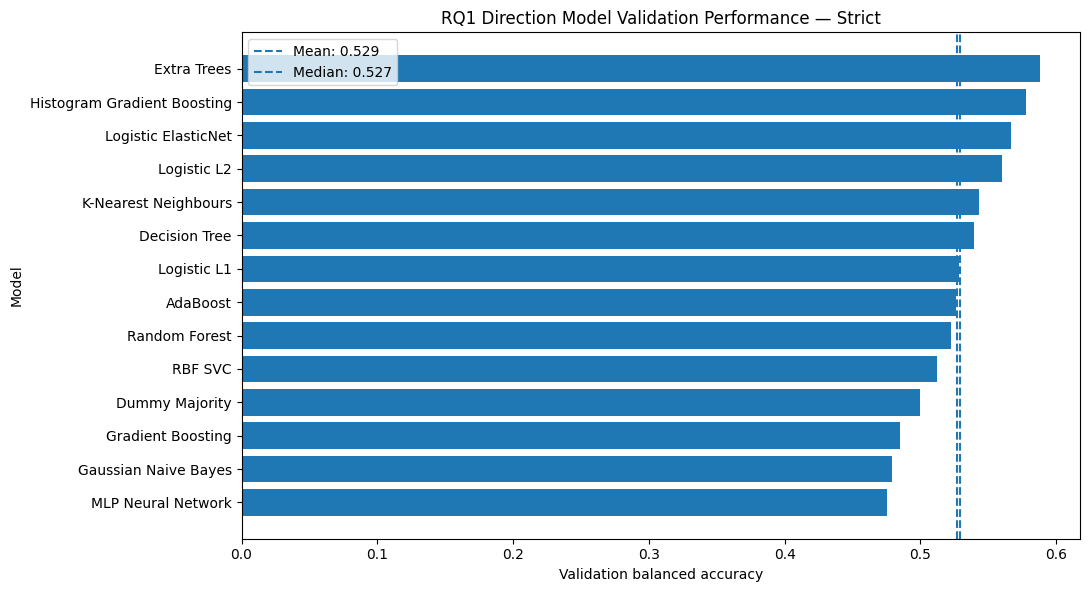

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\figures\rq1_direction_models_strict.png


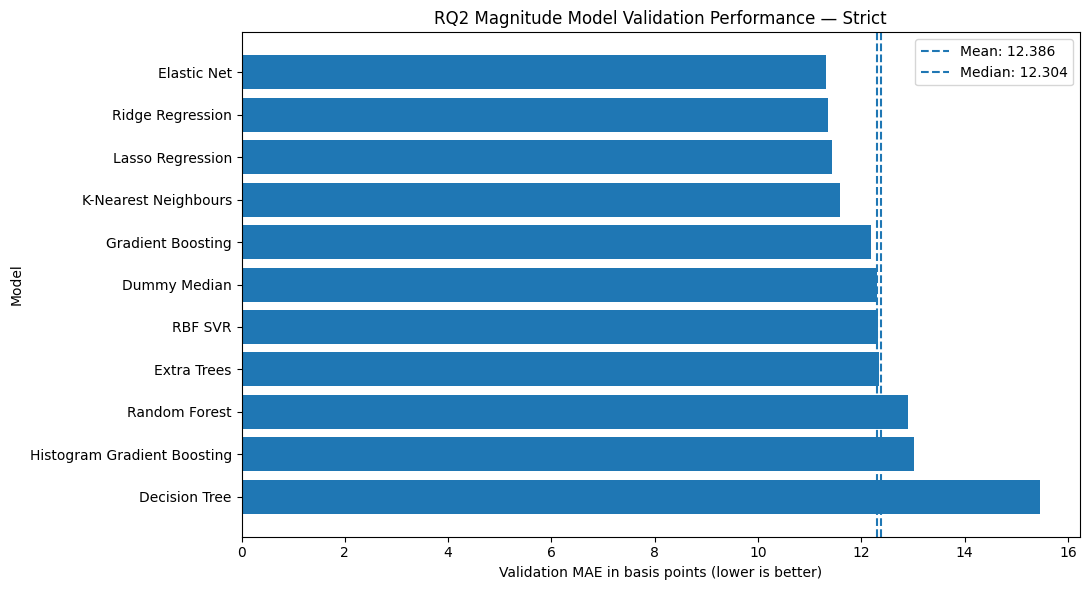

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\figures\rq2_magnitude_models_strict.png


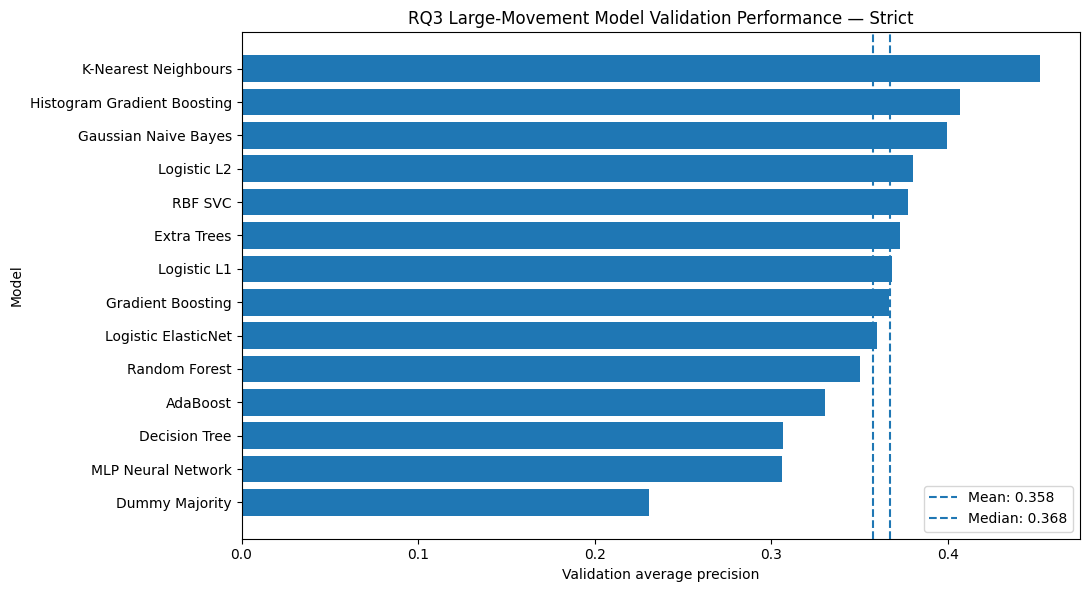

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\figures\rq3_large_move_models_strict.png


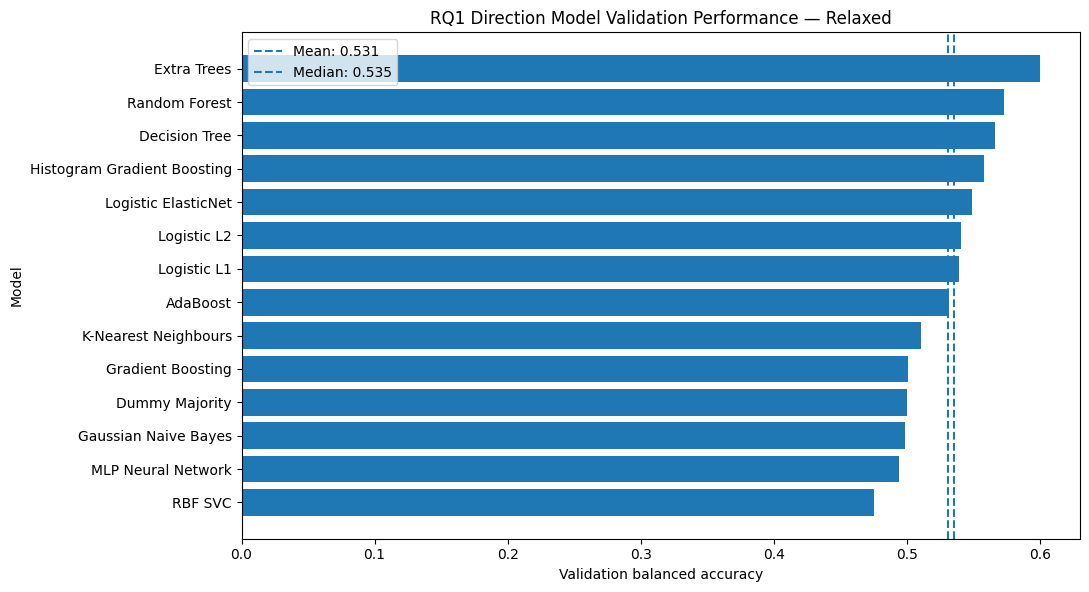

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\figures\rq1_direction_models_relaxed.png


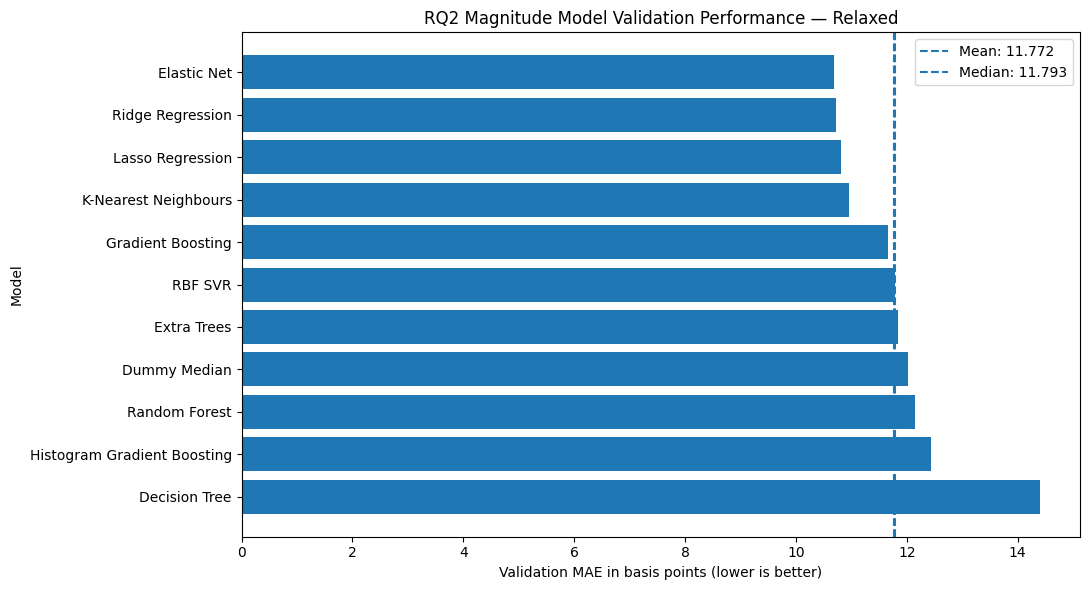

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\figures\rq2_magnitude_models_relaxed.png


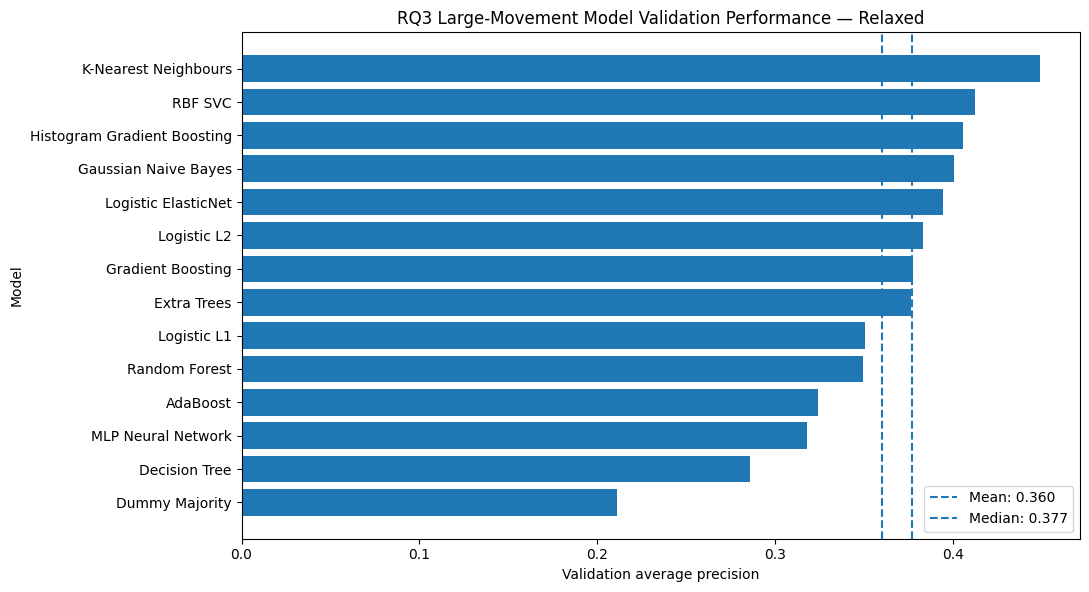

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\figures\rq3_large_move_models_relaxed.png


In [11]:
def model_ranking_plot(
    results: pd.DataFrame,
    variant: str,
    metric: str,
    title: str,
    xlabel: str,
    filename: str,
    higher_is_better: bool = True,
):
    plot_data = (
        results[
            results["dataset_variant"].eq(variant)
        ][["model", metric]]
        .dropna()
        .sort_values(
            metric,
            ascending=not higher_is_better,
        )
    )

    mean_value = plot_data[metric].mean()
    median_value = plot_data[metric].median()

    fig, ax = plt.subplots(
        figsize=(11, max(6, len(plot_data) * 0.43))
    )

    ax.barh(
        plot_data["model"],
        plot_data[metric],
    )

    ax.invert_yaxis()
    ax.axvline(
        mean_value,
        linestyle="--",
        label=f"Mean: {mean_value:.3f}",
    )
    ax.axvline(
        median_value,
        linestyle="--",
        label=f"Median: {median_value:.3f}",
    )

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Model")
    ax.legend()

    path = save_figure(fig, filename)
    plt.show()

    print("Saved:", path)


for variant in datasets:
    model_ranking_plot(
        rq1_results,
        variant,
        metric="validation_balanced_accuracy",
        title=(
            f"RQ1 Direction Model Validation Performance — {variant}"
        ),
        xlabel="Validation balanced accuracy",
        filename=f"rq1_direction_models_{variant.lower()}.png",
        higher_is_better=True,
    )

    model_ranking_plot(
        rq2_results,
        variant,
        metric="validation_mae_bps",
        title=(
            f"RQ2 Magnitude Model Validation Performance — {variant}"
        ),
        xlabel="Validation MAE in basis points (lower is better)",
        filename=f"rq2_magnitude_models_{variant.lower()}.png",
        higher_is_better=False,
    )

    model_ranking_plot(
        rq3_results,
        variant,
        metric="validation_average_precision",
        title=(
            f"RQ3 Large-Movement Model Validation Performance — {variant}"
        ),
        xlabel="Validation average precision",
        filename=f"rq3_large_move_models_{variant.lower()}.png",
        higher_is_better=True,
    )

## 9. Select provisional validation winners

These selections are provisional. They use validation performance only and do not inspect the test period.

In [12]:
rq1_winner = rq1_results.iloc[0].to_dict()
rq2_winner = rq2_results.iloc[0].to_dict()
rq3_winner = rq3_results.iloc[0].to_dict()

provisional_winners = pd.DataFrame(
    [
        {
            "research_question": "RQ1 Direction",
            "dataset_variant": rq1_winner["dataset_variant"],
            "model": rq1_winner["model"],
            "primary_metric": "Balanced accuracy",
            "validation_score": rq1_winner[
                "validation_balanced_accuracy"
            ],
            "cv_score": rq1_winner[
                "cv_balanced_accuracy_mean"
            ],
        },
        {
            "research_question": "RQ2 Magnitude",
            "dataset_variant": rq2_winner["dataset_variant"],
            "model": rq2_winner["model"],
            "primary_metric": "MAE in basis points",
            "validation_score": rq2_winner[
                "validation_mae_bps"
            ],
            "cv_score": rq2_winner[
                "cv_mae_bps_mean"
            ],
        },
        {
            "research_question": "RQ3 Large Movement",
            "dataset_variant": rq3_winner["dataset_variant"],
            "model": rq3_winner["model"],
            "primary_metric": "Average precision",
            "validation_score": rq3_winner[
                "validation_average_precision"
            ],
            "cv_score": rq3_winner[
                "cv_average_precision_mean"
            ],
        },
    ]
)

display(provisional_winners)

WINNERS_PATH = TABLE_ROOT / "provisional_validation_winners.csv"
provisional_winners.to_csv(WINNERS_PATH, index=False)
print("Saved:", WINNERS_PATH)

,research_question,dataset_variant,model,primary_metric,validation_score,cv_score
0,RQ1 Direction,Relaxed,Extra Trees,Balanced accuracy,0.600160,0.496626
1,RQ2 Magnitude,Relaxed,Elastic Net,MAE in basis points,10.694730,15.854354
2,RQ3 Large Movement,Strict,K-Nearest Neighbours,Average precision,0.452307,0.526962


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\tables\provisional_validation_winners.csv


## 10. Validation-period feature importance for RQ3

Permutation importance measures how much validation performance decreases when one feature is shuffled. It is model-dependent and may distribute importance across correlated features.

The notebook therefore reports both individual features and aggregated economic feature families.

,feature,importance_mean,importance_std,feature_group
0,momentum_accel_60m_vs_prior,0.065134,0.030957,Momentum
1,spy_volume_accel_60m_vs_avg,0.061947,0.026052,Volume and VWAP
2,realized_vol_30m,0.055977,0.029065,Volatility
3,realized_vol_60m,0.054062,0.028005,Volatility
4,spy_cum_volume_to_1500,0.050465,0.025718,Volume and VWAP
5,ret_last_60m,0.038715,0.047281,Momentum
6,spy_volume_last_30m,0.037772,0.037776,Volume and VWAP
7,realized_vol_120m,0.037294,0.032264,Volatility
8,ret_last_30m,0.035720,0.035795,Momentum
9,spy_volume_last_60m,0.034363,0.022523,Volume and VWAP


,feature_group,total_positive_importance,mean_importance,maximum_feature_importance
4,Volume and VWAP,0.184547,0.034690,0.061947
3,Volatility,0.184531,0.036906,0.055977
0,Momentum,0.181740,0.036348,0.065134
2,VIX,0.035388,0.002525,0.025190
1,Price positioning,0.000000,-0.023425,-0.004315


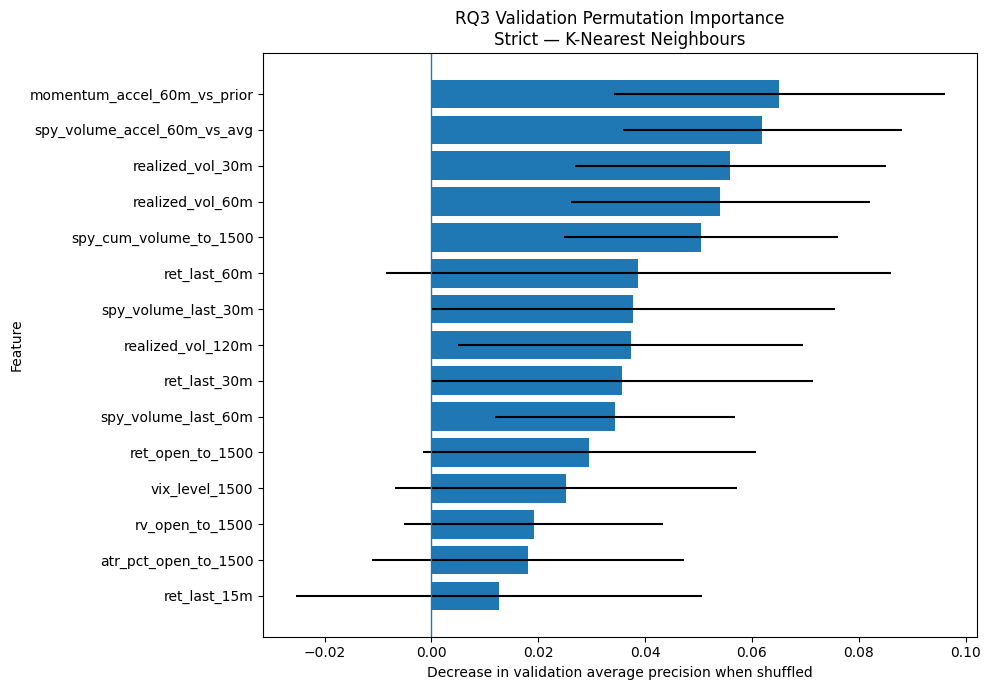

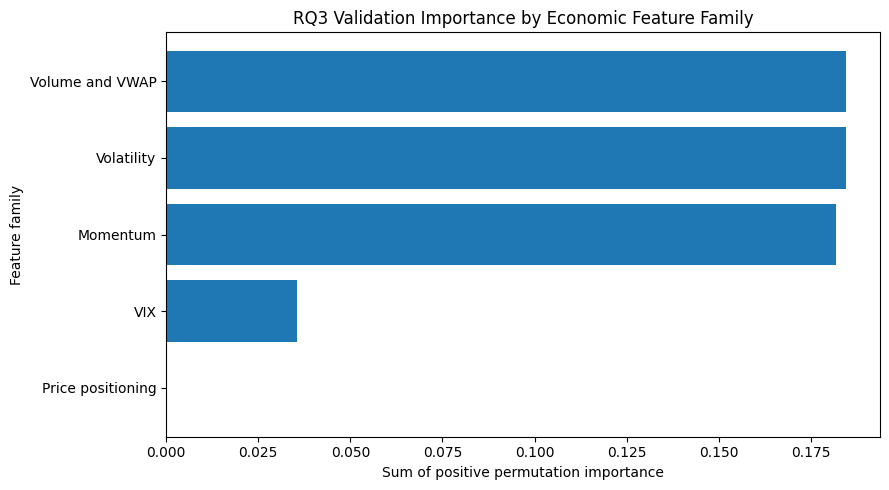

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\tables\rq3_validation_permutation_importance.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\tables\rq3_validation_group_importance.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\figures\rq3_validation_feature_importance.png
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\figures\rq3_validation_group_importance.png


In [13]:
def get_model_template(
    task: str,
    model_name: str,
):
    if task in {"RQ1", "RQ3"}:
        return CLASSIFICATION_MODELS[model_name]

    return REGRESSION_MODELS[model_name]


def fit_validation_model(
    frame: pd.DataFrame,
    model_template,
    target_column: str,
):
    train = frame[
        frame["data_split"].eq("Train")
    ].sort_values("session_date")

    validation = frame[
        frame["data_split"].eq("Validation")
    ].sort_values("session_date")

    model = clone(model_template)

    model.fit(
        train[BASE_FEATURES],
        train[target_column],
    )

    return model, train, validation


rq3_variant = rq3_winner["dataset_variant"]
rq3_model_name = rq3_winner["model"]
rq3_frame = datasets[rq3_variant]

rq3_model, rq3_train, rq3_validation = fit_validation_model(
    rq3_frame,
    CLASSIFICATION_MODELS[rq3_model_name],
    "target_large_move",
)

rq3_importance = permutation_importance(
    rq3_model,
    rq3_validation[BASE_FEATURES],
    rq3_validation["target_large_move"],
    scoring="average_precision",
    n_repeats=40,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

rq3_feature_importance = pd.DataFrame(
    {
        "feature": BASE_FEATURES,
        "importance_mean": rq3_importance.importances_mean,
        "importance_std": rq3_importance.importances_std,
    }
)

rq3_feature_importance["feature_group"] = (
    rq3_feature_importance["feature"].map(
        {
            feature: group
            for group, features in FEATURE_GROUPS.items()
            for feature in features
        }
    )
)

rq3_feature_importance = rq3_feature_importance.sort_values(
    "importance_mean",
    ascending=False,
).reset_index(drop=True)

display(rq3_feature_importance)

group_importance = (
    rq3_feature_importance.assign(
        positive_importance=lambda frame: frame[
            "importance_mean"
        ].clip(lower=0)
    )
    .groupby("feature_group", as_index=False)
    .agg(
        total_positive_importance=(
            "positive_importance",
            "sum",
        ),
        mean_importance=(
            "importance_mean",
            "mean",
        ),
        maximum_feature_importance=(
            "importance_mean",
            "max",
        ),
    )
    .sort_values(
        "total_positive_importance",
        ascending=False,
    )
)

display(group_importance)

RQ3_IMPORTANCE_PATH = (
    TABLE_ROOT
    / "rq3_validation_permutation_importance.csv"
)

RQ3_GROUP_PATH = (
    TABLE_ROOT
    / "rq3_validation_group_importance.csv"
)

rq3_feature_importance.to_csv(
    RQ3_IMPORTANCE_PATH,
    index=False,
)

group_importance.to_csv(
    RQ3_GROUP_PATH,
    index=False,
)

top_features = rq3_feature_importance.head(15).sort_values(
    "importance_mean"
)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(
    top_features["feature"],
    top_features["importance_mean"],
    xerr=top_features["importance_std"],
)
ax.axvline(0, linewidth=1)
ax.set_title(
    f"RQ3 Validation Permutation Importance\n"
    f"{rq3_variant} — {rq3_model_name}"
)
ax.set_xlabel(
    "Decrease in validation average precision when shuffled"
)
ax.set_ylabel("Feature")
path = save_figure(
    fig,
    "rq3_validation_feature_importance.png",
)
plt.show()

group_plot = group_importance.sort_values(
    "total_positive_importance"
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    group_plot["feature_group"],
    group_plot["total_positive_importance"],
)
ax.set_title(
    "RQ3 Validation Importance by Economic Feature Family"
)
ax.set_xlabel("Sum of positive permutation importance")
ax.set_ylabel("Feature family")
group_path = save_figure(
    fig,
    "rq3_validation_group_importance.png",
)
plt.show()

print("Saved:", RQ3_IMPORTANCE_PATH)
print("Saved:", RQ3_GROUP_PATH)
print("Saved:", path)
print("Saved:", group_path)

## 11. Cross-question feature importance

RQ3 is the primary feature-importance analysis, but feature relevance may differ between predicting direction, magnitude and large movements.

This section computes validation permutation importance for each provisional winner and combines the results.

In [14]:
winner_specifications = [
    {
        "research_question": "RQ1 Direction",
        "variant": rq1_winner["dataset_variant"],
        "model_name": rq1_winner["model"],
        "model_template": CLASSIFICATION_MODELS[
            rq1_winner["model"]
        ],
        "target": "target_up",
        "scoring": "balanced_accuracy",
    },
    {
        "research_question": "RQ2 Magnitude",
        "variant": rq2_winner["dataset_variant"],
        "model_name": rq2_winner["model"],
        "model_template": REGRESSION_MODELS[
            rq2_winner["model"]
        ],
        "target": "target_magnitude_bps",
        "scoring": "neg_mean_absolute_error",
    },
    {
        "research_question": "RQ3 Large Movement",
        "variant": rq3_winner["dataset_variant"],
        "model_name": rq3_winner["model"],
        "model_template": CLASSIFICATION_MODELS[
            rq3_winner["model"]
        ],
        "target": "target_large_move",
        "scoring": "average_precision",
    },
]

cross_question_rows = []

for specification in winner_specifications:
    frame = datasets[
        specification["variant"]
    ]

    model, train, validation = fit_validation_model(
        frame,
        specification["model_template"],
        specification["target"],
    )

    importance = permutation_importance(
        model,
        validation[BASE_FEATURES],
        validation[specification["target"]],
        scoring=specification["scoring"],
        n_repeats=30,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    for feature, mean_value, std_value in zip(
        BASE_FEATURES,
        importance.importances_mean,
        importance.importances_std,
    ):
        cross_question_rows.append(
            {
                "research_question": specification[
                    "research_question"
                ],
                "dataset_variant": specification[
                    "variant"
                ],
                "model": specification[
                    "model_name"
                ],
                "feature": feature,
                "feature_group": next(
                    group
                    for group, features in FEATURE_GROUPS.items()
                    if feature in features
                ),
                "importance_mean": mean_value,
                "importance_std": std_value,
            }
        )

cross_question_importance = pd.DataFrame(
    cross_question_rows
)

display(
    cross_question_importance.sort_values(
        [
            "research_question",
            "importance_mean",
        ],
        ascending=[True, False],
    )
)

cross_group_importance = (
    cross_question_importance.assign(
        positive_importance=lambda frame: frame[
            "importance_mean"
        ].clip(lower=0)
    )
    .groupby(
        [
            "research_question",
            "feature_group",
        ],
        as_index=False,
    )
    .agg(
        total_positive_importance=(
            "positive_importance",
            "sum",
        ),
        mean_importance=(
            "importance_mean",
            "mean",
        ),
    )
)

display(cross_group_importance)

CROSS_FEATURE_PATH = (
    TABLE_ROOT
    / "cross_question_validation_feature_importance.csv"
)

CROSS_GROUP_PATH = (
    TABLE_ROOT
    / "cross_question_validation_group_importance.csv"
)

cross_question_importance.to_csv(
    CROSS_FEATURE_PATH,
    index=False,
)

cross_group_importance.to_csv(
    CROSS_GROUP_PATH,
    index=False,
)

print("Saved:", CROSS_FEATURE_PATH)
print("Saved:", CROSS_GROUP_PATH)

,research_question,dataset_variant,model,feature,feature_group,importance_mean,importance_std
3,RQ1 Direction,Relaxed,Extra Trees,ret_last_60m,Momentum,0.045019,0.025864
8,RQ1 Direction,Relaxed,Extra Trees,vix_ret_last_60m,VIX,0.034642,0.017983
10,RQ1 Direction,Relaxed,Extra Trees,realized_vol_60m,Volatility,0.033226,0.015454
4,RQ1 Direction,Relaxed,Extra Trees,momentum_accel_60m_vs_prior,Momentum,0.023010,0.015151
18,RQ1 Direction,Relaxed,Extra Trees,position_in_day_range,Price positioning,0.019071,0.037954
...,...,...,...,...,...,...,...
64,RQ3 Large Movement,Strict,K-Nearest Neighbours,dist_from_day_low_pct,Price positioning,-0.003955,0.036200
61,RQ3 Large Movement,Strict,K-Nearest Neighbours,spy_dist_from_vwap_pct,Volume and VWAP,-0.011817,0.035240
62,RQ3 Large Movement,Strict,K-Nearest Neighbours,position_in_day_range,Price positioning,-0.011931,0.028221
51,RQ3 Large Movement,Strict,K-Nearest Neighbours,vix_ret_last_30m,VIX,-0.021365,0.034867


,research_question,feature_group,total_positive_importance,mean_importance
0,RQ1 Direction,Momentum,0.082879,0.016322
1,RQ1 Direction,Price positioning,0.037941,0.012647
2,RQ1 Direction,VIX,0.042388,0.007619
3,RQ1 Direction,Volatility,0.071034,0.014207
4,RQ1 Direction,Volume and VWAP,0.056811,0.011362
5,RQ2 Magnitude,Momentum,3.256330,0.642905
6,RQ2 Magnitude,Price positioning,3.537928,1.179309
7,RQ2 Magnitude,VIX,2.651187,0.642385
8,RQ2 Magnitude,Volatility,2.237686,0.447537
9,RQ2 Magnitude,Volume and VWAP,0.988781,0.197756


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\tables\cross_question_validation_feature_importance.csv
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\tables\cross_question_validation_group_importance.csv


## 12. Validation-based research-question summary

These statements are provisional and must be confirmed on the untouched test period.

### RQ1 decision logic

Evidence of directional predictability requires the leading model to:

- outperform the training-majority and simple rule baselines;
- exceed approximately 0.50 balanced accuracy;
- show similar performance across expanding folds and validation;
- avoid relying on one isolated validation regime.

### RQ2 decision logic

Evidence of magnitude predictability requires the leading model to:

- achieve lower validation MAE than the dummy median regressor;
- preferably produce positive out-of-sample R²;
- show a positive rank correlation between predicted and realised magnitude.

### RQ3 decision logic

Evidence of large-movement predictability requires the leading model to:

- improve average precision over the validation large-move prevalence;
- retain useful recall without predicting nearly every session as large;
- show feature importance that is reasonably stable across model families or feature groups.

A model ranking alone does not establish that the research question has been answered positively. The relevant benchmark and uncertainty must also be considered.

In [15]:
best_rule = (
    rule_results.sort_values(
        "balanced_accuracy",
        ascending=False,
    )
    .iloc[0]
)

rq1_summary = {
    "best_variant": rq1_winner["dataset_variant"],
    "best_model": rq1_winner["model"],
    "validation_balanced_accuracy": rq1_winner[
        "validation_balanced_accuracy"
    ],
    "best_rule_baseline": best_rule["rule"],
    "best_rule_balanced_accuracy": best_rule[
        "balanced_accuracy"
    ],
}

rq2_dummy = rq2_results[
    rq2_results["model"].eq("Dummy Median")
].sort_values("validation_mae_bps").iloc[0]

rq2_summary = {
    "best_variant": rq2_winner["dataset_variant"],
    "best_model": rq2_winner["model"],
    "validation_mae_bps": rq2_winner[
        "validation_mae_bps"
    ],
    "best_dummy_mae_bps": rq2_dummy[
        "validation_mae_bps"
    ],
    "mae_improvement_bps": (
        rq2_dummy["validation_mae_bps"]
        - rq2_winner["validation_mae_bps"]
    ),
    "validation_r2": rq2_winner[
        "validation_r2"
    ],
    "validation_spearman": rq2_winner[
        "validation_spearman"
    ],
}

rq3_variant_frame = datasets[
    rq3_winner["dataset_variant"]
]

rq3_validation_prevalence = (
    rq3_variant_frame.loc[
        rq3_variant_frame["data_split"].eq(
            "Validation"
        ),
        "target_large_move",
    ].mean()
)

rq3_summary = {
    "large_move_threshold_bps": LARGE_MOVE_THRESHOLD_BPS,
    "best_variant": rq3_winner["dataset_variant"],
    "best_model": rq3_winner["model"],
    "validation_average_precision": rq3_winner[
        "validation_average_precision"
    ],
    "validation_large_move_prevalence": (
        rq3_validation_prevalence
    ),
    "average_precision_improvement": (
        rq3_winner["validation_average_precision"]
        - rq3_validation_prevalence
    ),
    "top_feature_group": (
        group_importance.iloc[0]["feature_group"]
        if len(group_importance)
        else None
    ),
}

validation_rq_summary = {
    "RQ1": rq1_summary,
    "RQ2": rq2_summary,
    "RQ3": rq3_summary,
}

display(
    pd.DataFrame(
        [
            {
                "research_question": key,
                **value,
            }
            for key, value in validation_rq_summary.items()
        ]
    )
)

VALIDATION_SUMMARY_PATH = (
    MODEL_ROOT
    / "validation_research_question_summary.json"
)

with open(
    VALIDATION_SUMMARY_PATH,
    "w",
    encoding="utf-8",
) as summary_file:
    json.dump(
        validation_rq_summary,
        summary_file,
        indent=2,
        default=float,
    )

print(
    json.dumps(
        validation_rq_summary,
        indent=2,
        default=float,
    )
)
print("Saved:", VALIDATION_SUMMARY_PATH)

,research_question,best_variant,best_model,validation_balanced_accuracy,best_rule_baseline,best_rule_balanced_accuracy,validation_mae_bps,best_dummy_mae_bps,mae_improvement_bps,validation_r2,validation_spearman,large_move_threshold_bps,validation_average_precision,validation_large_move_prevalence,average_precision_improvement,top_feature_group
0,RQ1,Relaxed,Extra Trees,0.600160,60m Mean Reversion,0.595307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,RQ2,Relaxed,Elastic Net,NaN,NaN,NaN,10.694730,12.013308,1.318578,0.215806,0.445775,NaN,NaN,NaN,NaN,NaN
2,RQ3,Strict,K-Nearest Neighbours,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.504042,0.452307,0.230769,0.221538,Volume and VWAP


{
  "RQ1": {
    "best_variant": "Relaxed",
    "best_model": "Extra Trees",
    "validation_balanced_accuracy": 0.6001602564102564,
    "best_rule_baseline": "60m Mean Reversion",
    "best_rule_balanced_accuracy": 0.5953065134099617
  },
  "RQ2": {
    "best_variant": "Relaxed",
    "best_model": "Elastic Net",
    "validation_mae_bps": 10.694730402788396,
    "best_dummy_mae_bps": 12.01330841494144,
    "mae_improvement_bps": 1.3185780121530435,
    "validation_r2": 0.21580585602222357,
    "validation_spearman": 0.4457746478873239
  },
  "RQ3": {
    "large_move_threshold_bps": 27.504041884352514,
    "best_variant": "Strict",
    "best_model": "K-Nearest Neighbours",
    "validation_average_precision": 0.4523068108362226,
    "validation_large_move_prevalence": 0.23076923076923078,
    "average_precision_improvement": 0.2215375800669918,
    "top_feature_group": "Volume and VWAP"
  }
}
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\validation_r

# 13. Locked final test evaluation

Do not enable this section until:

1. the preferred dataset variant has been selected;
2. the model for each research question has been selected;
3. the feature list has been frozen;
4. the large-movement threshold has been frozen;
5. no further decisions will be based on test performance.

When enabled, each winning model is refitted using Train + Validation and evaluated once on Test.

In [20]:
RUN_FINAL_TEST = True

if not RUN_FINAL_TEST:
    print(
        "Final test evaluation is locked. "
        "Review all validation outputs before changing "
        "RUN_FINAL_TEST to True."
    )

In [21]:
def bootstrap_metric_interval(
    y_true,
    predictions,
    metric_function,
    n_bootstrap: int = 2_000,
    random_state: int = RANDOM_STATE,
):
    generator = np.random.default_rng(random_state)
    y_true = np.asarray(y_true)
    predictions = np.asarray(predictions)

    values = []

    for _ in range(n_bootstrap):
        indices = generator.integers(
            0,
            len(y_true),
            len(y_true),
        )

        sampled_y = y_true[indices]
        sampled_prediction = predictions[indices]

        try:
            value = metric_function(
                sampled_y,
                sampled_prediction,
            )

            if np.isfinite(value):
                values.append(value)
        except Exception:
            continue

    if not values:
        return np.nan, np.nan

    return (
        float(np.quantile(values, 0.025)),
        float(np.quantile(values, 0.975)),
    )


def final_classification_test(
    winner: dict,
    target_column: str,
    task_name: str,
):
    variant = winner["dataset_variant"]
    model_name = winner["model"]
    frame = datasets[variant]

    development = frame[
        frame["data_split"].isin(
            ["Train", "Validation"]
        )
    ].sort_values("session_date")

    test = frame[
        frame["data_split"].eq("Test")
    ].sort_values("session_date")

    model = clone(
        CLASSIFICATION_MODELS[model_name]
    )

    model.fit(
        development[BASE_FEATURES],
        development[target_column],
    )

    prediction = model.predict(
        test[BASE_FEATURES]
    )

    probability = probability_predictions(
        model,
        test[BASE_FEATURES],
    )

    metrics = classification_metrics(
        test[target_column],
        prediction,
        probability,
    )

    ba_interval = bootstrap_metric_interval(
        test[target_column],
        prediction,
        balanced_accuracy_score,
    )

    metrics.update(
        {
            "task": task_name,
            "dataset_variant": variant,
            "model": model_name,
            "test_sessions": len(test),
            "balanced_accuracy_ci_low": ba_interval[0],
            "balanced_accuracy_ci_high": ba_interval[1],
        }
    )

    return model, test, prediction, probability, metrics


def final_regression_test(
    winner: dict,
):
    variant = winner["dataset_variant"]
    model_name = winner["model"]
    frame = datasets[variant]

    development = frame[
        frame["data_split"].isin(
            ["Train", "Validation"]
        )
    ].sort_values("session_date")

    test = frame[
        frame["data_split"].eq("Test")
    ].sort_values("session_date")

    model = clone(
        REGRESSION_MODELS[model_name]
    )

    model.fit(
        development[BASE_FEATURES],
        development["target_magnitude_bps"],
    )

    prediction = model.predict(
        test[BASE_FEATURES]
    )

    metrics = regression_metrics(
        test["target_magnitude_bps"],
        prediction,
    )

    mae_interval = bootstrap_metric_interval(
        test["target_magnitude_bps"],
        prediction,
        mean_absolute_error,
    )

    metrics.update(
        {
            "task": "RQ2 Magnitude",
            "dataset_variant": variant,
            "model": model_name,
            "test_sessions": len(test),
            "mae_ci_low": mae_interval[0],
            "mae_ci_high": mae_interval[1],
        }
    )

    return model, test, prediction, metrics


if RUN_FINAL_TEST:
    (
        final_rq1_model,
        final_rq1_test,
        final_rq1_prediction,
        final_rq1_probability,
        final_rq1_metrics,
    ) = final_classification_test(
        rq1_winner,
        target_column="target_up",
        task_name="RQ1 Direction",
    )

    (
        final_rq2_model,
        final_rq2_test,
        final_rq2_prediction,
        final_rq2_metrics,
    ) = final_regression_test(
        rq2_winner,
    )

    (
        final_rq3_model,
        final_rq3_test,
        final_rq3_prediction,
        final_rq3_probability,
        final_rq3_metrics,
    ) = final_classification_test(
        rq3_winner,
        target_column="target_large_move",
        task_name="RQ3 Large Movement",
    )

    final_test_results = pd.DataFrame(
        [
            final_rq1_metrics,
            final_rq2_metrics,
            final_rq3_metrics,
        ]
    )

    display(final_test_results)

    FINAL_TEST_PATH = (
        TABLE_ROOT
        / "final_locked_test_results.csv"
    )

    final_test_results.to_csv(
        FINAL_TEST_PATH,
        index=False,
    )

    print("Saved:", FINAL_TEST_PATH)

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision,mcc,brier,log_loss,task,dataset_variant,model,test_sessions,balanced_accuracy_ci_low,balanced_accuracy_ci_high,mae_bps,rmse_bps,r2,spearman,mae_ci_low,mae_ci_high
0,0.469136,0.453548,0.577778,0.520000,0.547368,0.503871,0.696374,-0.090874,0.250369,0.693861,RQ1 Direction,Relaxed,Extra Trees,81,0.341667,0.566321,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RQ2 Magnitude,Relaxed,Elastic Net,81,NaN,NaN,10.817361,14.976221,0.051682,0.334282,8.763159,13.222685
2,0.787879,0.513889,0.250000,0.083333,0.125000,0.746142,0.351290,0.044901,0.132664,0.563091,RQ3 Large Movement,Strict,K-Nearest Neighbours,66,0.447354,0.616406,NaN,NaN,NaN,NaN,NaN,NaN


Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\tables\final_locked_test_results.csv


## 14. Final-test diagnostic plots

These plots run only after the test set is unlocked.

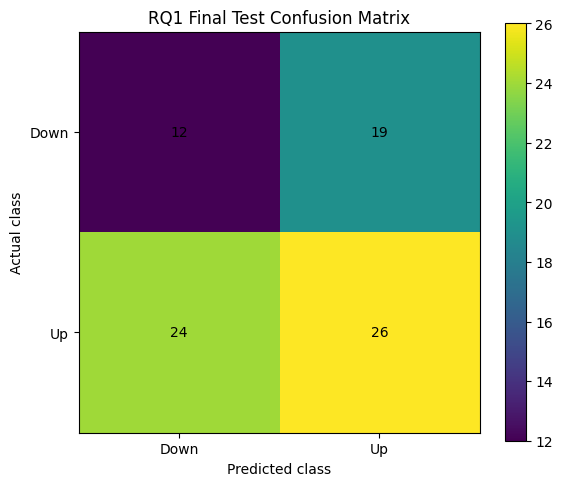

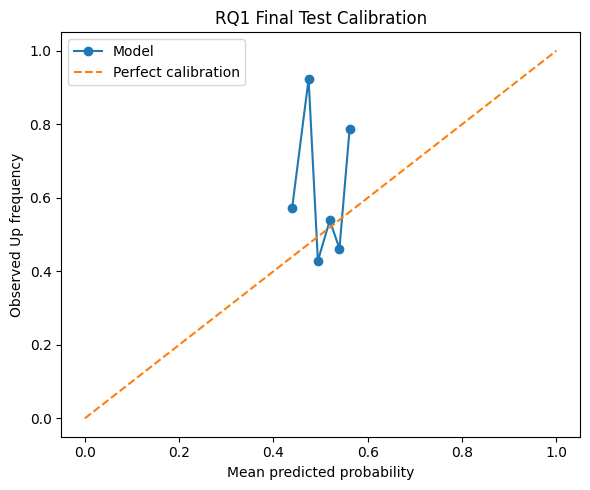

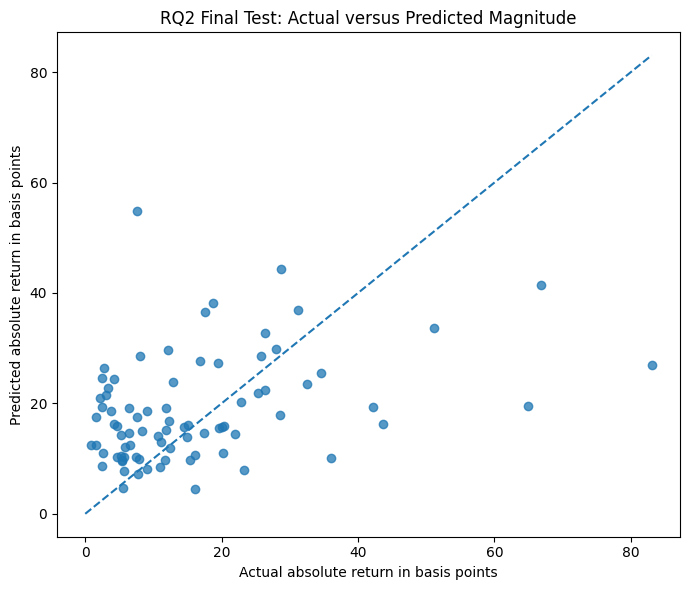

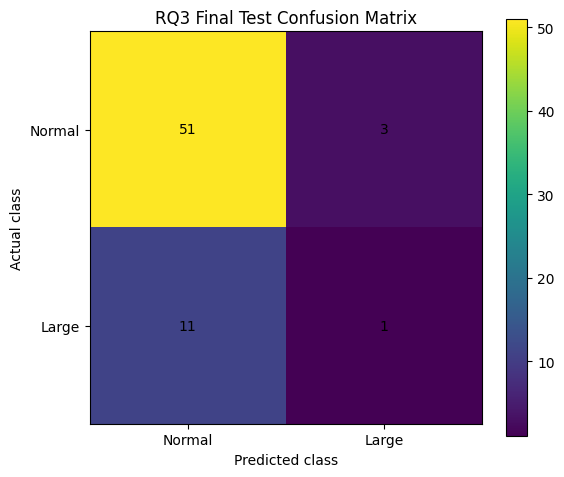

Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\figures\rq1_final_test_confusion_matrix.png
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\figures\rq1_final_test_calibration.png
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\figures\rq2_final_test_actual_vs_predicted.png
Saved: C:\Users\hkhat\OneDrive\Desktop\Project\Dissertation\outputs\baseline_models\figures\rq3_final_test_confusion_matrix.png


In [22]:
if RUN_FINAL_TEST:
    # RQ1 confusion matrix
    matrix = confusion_matrix(
        final_rq1_test["target_up"],
        final_rq1_prediction,
        labels=[0, 1],
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(matrix)

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            ax.text(
                column,
                row,
                matrix[row, column],
                ha="center",
                va="center",
            )

    ax.set_xticks([0, 1], ["Down", "Up"])
    ax.set_yticks([0, 1], ["Down", "Up"])
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_title("RQ1 Final Test Confusion Matrix")
    fig.colorbar(image, ax=ax)
    path = save_figure(
        fig,
        "rq1_final_test_confusion_matrix.png",
    )
    plt.show()

    # RQ1 calibration
    fraction_positive, mean_predicted = calibration_curve(
        final_rq1_test["target_up"],
        final_rq1_probability,
        n_bins=6,
        strategy="quantile",
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.plot(
        mean_predicted,
        fraction_positive,
        marker="o",
        label="Model",
    )
    ax.plot(
        [0, 1],
        [0, 1],
        linestyle="--",
        label="Perfect calibration",
    )
    ax.set_title("RQ1 Final Test Calibration")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed Up frequency")
    ax.legend()
    calibration_path = save_figure(
        fig,
        "rq1_final_test_calibration.png",
    )
    plt.show()

    # RQ2 actual versus predicted magnitude
    fig, ax = plt.subplots(figsize=(7, 6))
    ax.scatter(
        final_rq2_test["target_magnitude_bps"],
        final_rq2_prediction,
        alpha=0.75,
    )

    maximum = max(
        final_rq2_test["target_magnitude_bps"].max(),
        np.max(final_rq2_prediction),
    )

    ax.plot(
        [0, maximum],
        [0, maximum],
        linestyle="--",
    )
    ax.set_title("RQ2 Final Test: Actual versus Predicted Magnitude")
    ax.set_xlabel("Actual absolute return in basis points")
    ax.set_ylabel("Predicted absolute return in basis points")
    rq2_path = save_figure(
        fig,
        "rq2_final_test_actual_vs_predicted.png",
    )
    plt.show()

    # RQ3 confusion matrix
    matrix = confusion_matrix(
        final_rq3_test["target_large_move"],
        final_rq3_prediction,
        labels=[0, 1],
    )

    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(matrix)

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            ax.text(
                column,
                row,
                matrix[row, column],
                ha="center",
                va="center",
            )

    ax.set_xticks([0, 1], ["Normal", "Large"])
    ax.set_yticks([0, 1], ["Normal", "Large"])
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("Actual class")
    ax.set_title("RQ3 Final Test Confusion Matrix")
    fig.colorbar(image, ax=ax)
    rq3_path = save_figure(
        fig,
        "rq3_final_test_confusion_matrix.png",
    )
    plt.show()

    print("Saved:", path)
    print("Saved:", calibration_path)
    print("Saved:", rq2_path)
    print("Saved:", rq3_path)

## 15. Final outputs and interpretation workflow

### Before unlocking the test set

Review:

- strict versus relaxed performance;
- expanding-fold stability;
- validation performance relative to baselines;
- probability quality;
- large-move prevalence;
- feature-importance stability;
- whether any winner is only marginally better than a simpler model.

### After unlocking the test set

Answer the research questions conservatively:

- **RQ1:** conclude positively only if final balanced accuracy and related metrics exceed naive and rule-based baselines with acceptable uncertainty.
- **RQ2:** conclude positively only if final MAE improves on the median baseline and predicted magnitude is positively associated with realised magnitude.
- **RQ3:** report feature families that are consistently important for large-movement prediction, while acknowledging that correlated variables can share or dilute importance.

The options-data phase should measure incremental improvement over these underlying-only results rather than replacing the benchmark.

In [19]:
output_files = pd.DataFrame(
    {
        "artifact": [
            "RQ1 validation results",
            "RQ1 rule baselines",
            "RQ2 validation results",
            "RQ3 validation results",
            "Provisional validation winners",
            "RQ3 feature importance",
            "RQ3 grouped importance",
            "Cross-question feature importance",
            "Validation RQ summary",
            "Figure directory",
        ],
        "path": [
            str(RQ1_PATH),
            str(RULE_RESULTS_PATH),
            str(RQ2_PATH),
            str(RQ3_PATH),
            str(WINNERS_PATH),
            str(RQ3_IMPORTANCE_PATH),
            str(RQ3_GROUP_PATH),
            str(CROSS_FEATURE_PATH),
            str(VALIDATION_SUMMARY_PATH),
            str(FIGURE_ROOT),
        ],
    }
)

display(output_files)

print("Baseline modelling workflow completed.")
print(
    "The final test remains locked unless "
    "RUN_FINAL_TEST is explicitly set to True."
)

,artifact,path
0,RQ1 validation results,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
1,RQ1 rule baselines,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
2,RQ2 validation results,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
3,RQ3 validation results,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
4,Provisional validation winners,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
5,RQ3 feature importance,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
6,RQ3 grouped importance,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
7,Cross-question feature importance,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
8,Validation RQ summary,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...
9,Figure directory,C:\Users\hkhat\OneDrive\Desktop\Project\Disser...


Baseline modelling workflow completed.
The final test remains locked unless RUN_FINAL_TEST is explicitly set to True.
